#Forecasting Technique 1 – Moving Average

#📘 Moving Averages Overview

Moving averages smooth out time series data to identify trends by reducing noise. They are useful for:

>Smoothing fluctuations

>Highlighting long-term trends

>Creating indicators for trading strategies

#1️⃣ Simple Moving Average (SMA)

Definition:

The SMA is the average of the last n values.

Formula:

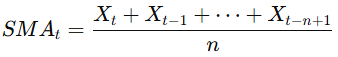

   Price      SMA_3
0     10        NaN
1     12        NaN
2     11  11.000000
3     13  12.000000
4     15  13.000000
5     16  14.666667
6     14  15.000000
7     13  14.333333
8     15  14.000000
9     16  14.666667


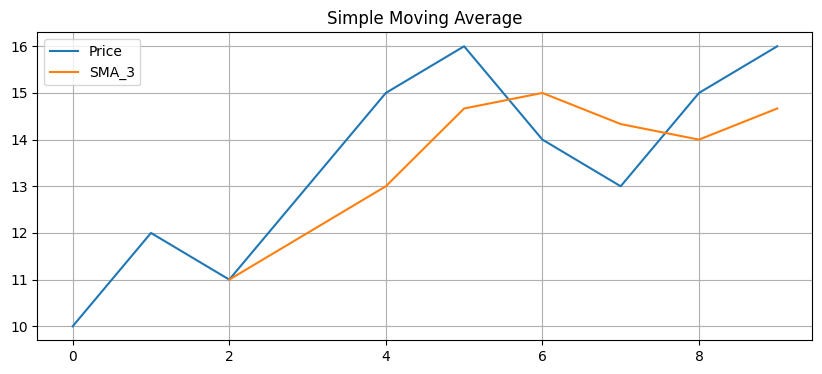

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Sample time series data
data = {'Price': [10, 12, 11, 13, 15, 16, 14, 13, 15, 16]}
df = pd.DataFrame(data)

# Simple Moving Average with window = 3
df['SMA_3'] = df['Price'].rolling(window=3).mean()

print(df)
df.plot(title="Simple Moving Average", figsize=(10, 4))
plt.grid()
plt.show()


#2️⃣ Exponential Moving Average (EMA)

Definition:

EMA assigns more weight to recent data.

Formula:

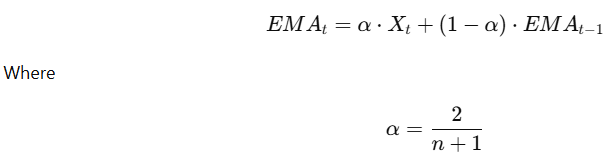

   Price      SMA_3      EMA_3
0     10        NaN  10.000000
1     12        NaN  11.000000
2     11  11.000000  11.000000
3     13  12.000000  12.000000
4     15  13.000000  13.500000
5     16  14.666667  14.750000
6     14  15.000000  14.375000
7     13  14.333333  13.687500
8     15  14.000000  14.343750
9     16  14.666667  15.171875


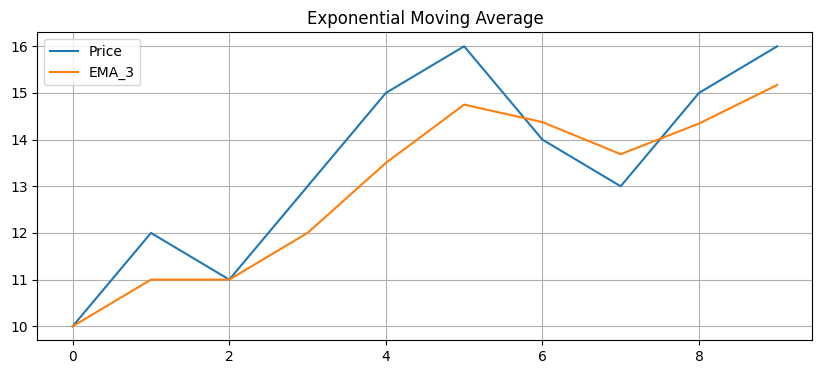

In [2]:
# Exponential Moving Average with span = 3
df['EMA_3'] = df['Price'].ewm(span=3, adjust=False).mean()

print(df)
df[['Price', 'EMA_3']].plot(title="Exponential Moving Average", figsize=(10, 4))
plt.grid()
plt.show()


#3️⃣ Weighted Moving Average (WMA)

Definition: WMA assigns linearly decreasing weights (e.g., 3,2,1) to recent values.

🔧 Code Example:

   Price      SMA_3      EMA_3      WMA_3
0     10        NaN  10.000000        NaN
1     12        NaN  11.000000        NaN
2     11  11.000000  11.000000  11.166667
3     13  12.000000  12.000000  12.166667
4     15  13.000000  13.500000  13.666667
5     16  14.666667  14.750000  15.166667
6     14  15.000000  14.375000  14.833333
7     13  14.333333  13.687500  13.833333
8     15  14.000000  14.343750  14.166667
9     16  14.666667  15.171875  15.166667


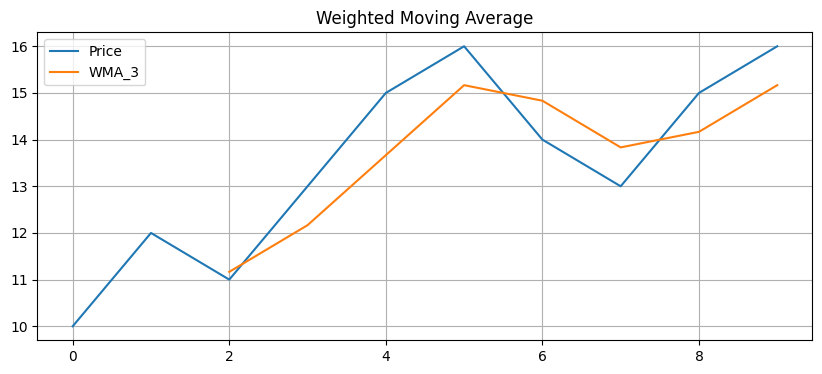

In [3]:
import numpy as np

def weighted_moving_average(series, window):
    weights = np.arange(1, window + 1)
    return series.rolling(window).apply(lambda x: np.dot(x, weights)/weights.sum(), raw=True)

# Weighted Moving Average with window = 3
df['WMA_3'] = weighted_moving_average(df['Price'], 3)

print(df)
df[['Price', 'WMA_3']].plot(title="Weighted Moving Average", figsize=(10, 4))
plt.grid()
plt.show()


#📊 Summary Table

| Type | Sensitivity | Weights           |
| ---- | ----------- | ----------------- |
| SMA  | Low         | Equal             |
| EMA  | High        | Exponential decay |
| WMA  | Medium      | Linear decay      |
